Let’s walk through **XGBoost regression** using your example:  
- **Input (X)**: CGPA (e.g., 7, 8, 9)  
- **Target (Y)**: Placement salary in lakhs (e.g., 5, 7, 10).  

We’ll use a small dataset for simplicity:

| CGPA (X) | Salary (Y) |
|----------|------------|
| 7        | 5          |
| 8        | 7          |
| 9        | 10         |

---

### **Step 1: Start with the Mean Model**
XGBoost begins by predicting the **average** of the target variable.  
$$
\text{Initial Prediction} = \frac{5 + 7 + 10}{3} = 7.33 \, \text{lakhs}
$$

---

### **Step 2: Compute Residuals (Errors)**
Residuals = Actual Salary - Initial Prediction:

| CGPA | Salary | Initial Prediction | Residual |
|------|--------|--------------------|----------|
| 7    | 5      | 7.33               | -2.33    |
| 8    | 7      | 7.33               | -0.33    |
| 9    | 10     | 7.33               | 2.67     |

These residuals represent errors in the initial prediction.

---

### **Step 3: Build a Tree to Predict Residuals**
XGBoost builds a **decision tree** to predict these residuals. It splits the data based on CGPA.

#### **Split 1: CGPA ≤ 8 vs. CGPA > 8**
- Left Node (CGPA ≤ 8): Samples [5, 7] → Residuals [-2.33, -0.33]  
- Right Node (CGPA > 8): Sample [10] → Residual [2.67]  

---

### **Step 4: Calculate Similarity Scores and Gain**
To decide if this split is good, XGBoost computes:  

#### **Similarity Score for Each Node**  
$$
\text{Similarity} = \frac{(\sum g_i)^2}{\sum h_i + \lambda}
$$
For **squared error loss**:  
- $ g_i = \text{Residual} $ (no need for Hessians $ h_i $ since they’re 1 for squared error).  
- $ \lambda $: Regularization parameter (e.g., 1).  

**Left Node**:  
$$
\text{Similarity}_{\text{left}} = \frac{(-2.33 - 0.33)^2}{2 + 1} = \frac{(-2.66)^2}{3} = \frac{7.08}{3} = 2.36
$$

**Right Node**:  
$$
\text{Similarity}_{\text{right}} = \frac{(2.67)^2}{1 + 1} = \frac{7.13}{2} = 3.57
$$

**Parent Node** (before split):  
$$
\text{Similarity}_{\text{parent}} = \frac{(-2.33 - 0.33 + 2.67)^2}{3 + 1} = \frac{(0.01)^2}{4} = 0.000025
$$

#### **Gain for the Split**  
$$
\text{Gain} = \frac{1}{2} \left[ \text{Similarity}_{\text{left}} + \text{Similarity}_{\text{right}} - \text{Similarity}_{\text{parent}} \right] - \gamma
$$
Assume $ \gamma = 0 $ (no minimum gain):  
$$
\text{Gain} = \frac{1}{2} (2.36 + 3.57 - 0.000025) = \frac{5.93}{2} = 2.97
$$

Since **Gain > 0**, the split is accepted.

---

### **Step 5: Assign Leaf Weights**
Leaf weight formula:  
$$
w_j = -\frac{\sum g_i}{H_j + \lambda}
$$
- **Left Leaf**:  
  $ w_{\text{left}} = -\frac{-2.66}{2 + 1} = \frac{2.66}{3} = 0.89 $  
- **Right Leaf**:  
  $ w_{\text{right}} = -\frac{2.67}{1 + 1} = -\frac{2.67}{2} = -1.34 $  

---

### **Step 6: Update Predictions**
Add the tree’s predictions to the initial model using a **learning rate** $ \eta $ (e.g., $ \eta = 0.3 $):

| CGPA | Initial Prediction | Tree Prediction | Updated Prediction |
|------|--------------------|------------------|---------------------|
| 7    | 7.33               | 0.3 × 0.89 = 0.27 | 7.33 + 0.27 = 7.60   |
| 8    | 7.33               | 0.3 × 0.89 = 0.27 | 7.33 + 0.27 = 7.60   |
| 9    | 7.33               | 0.3 × (-1.34) = -0.40 | 7.33 - 0.40 = 6.93 |

---

### **Step 7: Repeat for More Trees**
XGBoost repeats Steps 2–6 to reduce residuals further. For example:  
- Compute new residuals:  
  $ \text{New Residual} = \text{Actual Salary} - \text{Updated Prediction} $  
- Build another tree to fit these new residuals.  
- Add the new tree’s predictions to the model.  

After multiple iterations, predictions converge closer to actual salaries.

---

### **Final Prediction**
After 2–3 trees, the model might predict:  
- CGPA 7 → ~5.5 lakhs  
- CGPA 8 → ~7.0 lakhs  
- CGPA 9 → ~9.5 lakhs  

---

### **Key Concepts in Your Example**
1. **Mean Model**: Starts with average salary (7.33 lakhs).  
2. **Residuals**: Errors in initial prediction (e.g., -2.33 for CGPA 7).  
3. **Similarity Score**: Measures how well a split reduces errors.  
4. **Leaf Weights**: Adjust predictions for groups of CGPA values.  
5. **Learning Rate**: Slows updates to prevent overfitting (e.g., $ \eta = 0.3 $).  
6. **Regularization**: $ \lambda $ penalizes large leaf weights.  

---



Train RMSE: 0.008879899949831585
Train R²: 0.9999649524688721
Test Prediction: [7.008881]
Actual Test Value: [5]


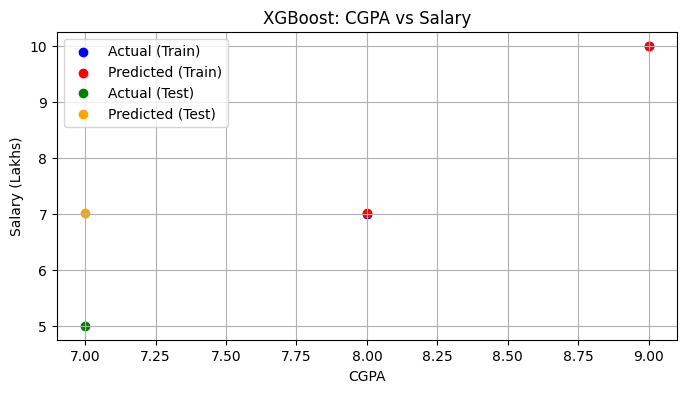

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Step 1: Create the dataset
data = {
    'CGPA': [7, 8, 9],          # Input feature (X)
    'Salary': [5, 7, 10]        # Target variable (Y)
}
df = pd.DataFrame(data)

# Step 2: Define features (X) and target (y)
X = df[['CGPA']]               # Features (2D array required)
y = df['Salary']               # Target

# Step 3: Split data into training and testing sets (even though tiny dataset)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Step 4: Initialize XGBoost Regressor
model = XGBRegressor(
    n_estimators=100,           # Number of trees
    learning_rate=0.1,          # Step size for updates
    max_depth=2,                # Depth of trees
    objective='reg:squarederror', # Loss function
    random_state=42
)

# Step 5: Train the model
model.fit(X_train, y_train)

# Step 6: Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Step 7: Evaluate the model
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Train R²:", r2_score(y_train, y_train_pred))
print("Test Prediction:", y_test_pred)
print("Actual Test Value:", y_test.values)

# Step 8: Visualize predictions vs actual
plt.figure(figsize=(8, 4))
plt.scatter(X_train['CGPA'], y_train, color='blue', label='Actual (Train)')
plt.scatter(X_train['CGPA'], y_train_pred, color='red', label='Predicted (Train)')
if len(X_test) > 0:
    plt.scatter(X_test['CGPA'], y_test, color='green', label='Actual (Test)')
    plt.scatter(X_test['CGPA'], y_test_pred, color='orange', label='Predicted (Test)')
plt.xlabel('CGPA')
plt.ylabel('Salary (Lakhs)')
plt.legend()
plt.title('XGBoost: CGPA vs Salary')
plt.grid(True)
plt.show()



---

### **1. Explain XGBoost in Simple Terms**
**Answer:**  
XGBoost is an ensemble machine learning algorithm that combines **gradient boosting** with **regularization** to improve performance. It builds decision trees sequentially, where each tree corrects the errors of the previous ones. Key features include:  
- **Gradient Boosting**: Minimizes errors using gradients of the loss function.  
- **Regularization**: Penalizes complex trees to avoid overfitting (L1/L2).  
- **Speed & Efficiency**: Uses parallel processing and optimized tree-splitting algorithms.  

**Example**: In predicting salaries from CGPA, XGBoost starts with an average prediction, iteratively corrects errors (e.g., underestimating high CGPAs), and combines trees to refine predictions.

---

### **2. How Is XGBoost Different from Random Forest?**
**Answer:**  
| **Aspect**               | **XGBoost**                          | **Random Forest**                     |  
|--------------------------|--------------------------------------|---------------------------------------|  
| **Ensemble Method**       | Boosting (sequential trees)          | Bagging (independent trees)           |  
| **Bias-Variance Tradeoff**| Reduces bias first, then variance    | Reduces variance directly             |  
| **Speed**                 | Slower (trees built sequentially)    | Faster (trees built in parallel)      |  
| **Overfitting**           | Prone to overfitting (if not tuned)  | Less prone (due to averaging)         |  
| **Handling Missing Data** | Built-in support                     | Requires preprocessing                |  

**Example**: For CGPA → Salary prediction, XGBoost might outperform Random Forest if the relationship is non-linear and complex, but it requires careful tuning.

---

### **3. How Does XGBoost Handle Overfitting?**
**Answer:**  
XGBoost uses **multiple techniques** to prevent overfitting:  
1. **Regularization**:  
   - L1 (α): Shrinks leaf weights and prunes trees.  
   - L2 (λ): Penalizes large leaf weights.  
2. **Tree Constraints**:  
   - `max_depth`: Limits tree depth.  
   - `min_child_weight`: Ensures sufficient samples per leaf.  
3. **Subsampling**:  
   - `subsample`: Trains trees on random subsets of data.  
   - `colsample_bytree`: Uses random subsets of features.  
4. **Early Stopping**: Halts training when validation performance plateaus.  

**Example**: In a tiny dataset (e.g., 3 CGPA-Salary pairs), setting `max_depth=1` prevents overfitting by forcing simple trees.

---

### **4. What Are the Key Hyperparameters in XGBoost?**
**Answer:**  
| **Hyperparameter**        | **Purpose**                          |  
|---------------------------|--------------------------------------|  
| `n_estimators`            | Number of trees (higher = better fit, but slower). |  
| `learning_rate` (η)       | Step size for updates (smaller = slower but more precise). |  
| `max_depth`               | Maximum depth of trees (controls complexity). |  
| `min_child_weight`        | Minimum sum of weights in a child node (prevents overfitting). |  
| `gamma`                   | Minimum loss reduction required to split (prunes trees). |  
| `subsample`               | Fraction of data used per tree (0.5–1.0). |  
| `colsample_bytree`        | Fraction of features used per tree. |  
| `reg_alpha` (α) / `reg_lambda` (λ) | L1/L2 regularization strength. |  

**Example**: For CGPA → Salary, tuning `max_depth=2` and `learning_rate=0.1` balances accuracy and speed.

---

### **5. What Role Does Regularization Play in XGBoost?**
**Answer:**  
Regularization in XGBoost penalizes complex trees to reduce overfitting:  
- **L1 Regularization (α)**: Adds a penalty proportional to the absolute value of weights, encouraging sparsity (zeroing out less important features/leaves).  
- **L2 Regularization (λ)**: Adds a penalty proportional to the square of weights, shrinking large weights.  
- **Gamma (γ)**: Minimum loss reduction required to split a node. If the gain from a split is less than γ, the split is abandoned.  

**Example**: If CGPA has noisy outliers (e.g., a student with CGPA 9 earns 1 lakh), regularization prevents the model from overfitting to these extremes.

---

### **6. How Does XGBoost Handle Missing Values?**
**Answer:**  
XGBoost handles missing values automatically:  
- During tree construction, it learns the **optimal default direction** (left or right) for missing values.  
- This avoids the need for preprocessing (e.g., imputation).  

**Example**: If a student’s CGPA is missing, XGBoost will assign it to the left or right branch based on what minimizes the loss.

---

### **7. How Does XGBoost Compute Feature Importance?**
**Answer:**  
XGBoost calculates feature importance using three metrics:  
1. **Weight**: Number of times a feature is used to split the data.  
2. **Gain**: Average improvement in model performance from splits using the feature.  
3. **Cover**: Average coverage (number of samples affected) by splits using the feature.  

**Example**: In CGPA → Salary, "CGPA" will have high gain, as it strongly influences salary predictions.

---

### **8. What’s the Difference Between GBM and XGBoost?**
**Answer:**  
| **Aspect**               | **GBM**                              | **XGBoost**                          |  
|--------------------------|--------------------------------------|--------------------------------------|  
| **Optimization**          | First-order gradient descent         | Second-order (Newton-Raphson)        |  
| **Regularization**        | Limited (no L1/L2)                   | Strong (L1/L2 + gamma)               |  
| **Speed**                 | Slower                               | Faster (parallel tree building)      |  
| **Missing Values**        | No built-in support                  | Built-in support                     |  
| **Performance**           | Good                                 | Better (winner of Kaggle contests)   |  

**Example**: For salary prediction, XGBoost will converge faster and generalize better than GBM.

---

### **9. How Does XGBoost Handle Imbalanced Datasets?**
**Answer:**  
XGBoost handles imbalance via:  
1. **Class Weights**: Use `scale_pos_weight` to penalize misclassification of the minority class.  
2. **Evaluation Metrics**: Use AUC-ROC instead of accuracy.  
3. **Resampling**: Combine with SMOTE/undersampling.  
4. **Hyperparameter Tuning**: Adjust `max_depth` and `learning_rate` for better convergence.  

**Example**: If only 10% of students have CGPA ≥ 9, `scale_pos_weight` ensures the model doesn’t ignore this group.

---

### **10. Explain the XGBoost Objective Function**
**Answer:**  
The objective function is:  
$$
\text{Obj} = \sum_{i=1}^n L(y_i, \hat{y}_i) + \sum_{k=1}^T \Omega(f_k)
$$  
Where:  
- $ L(y_i, \hat{y}_i) $: Loss function (e.g., squared error for regression).  
- $ \Omega(f_k) $: Regularization term for tree complexity:  
  $$
  \Omega(f) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^T w_j^2
  $$  
  - $ T $: Number of leaves.  
  - $ w_j $: Leaf weights.  
  - $ \gamma $: Penalty for adding a leaf.  
  - $ \lambda $: L2 regularization on weights.  

**Example**: For salary prediction, the objective balances minimizing prediction errors and keeping trees simple.

---

### **11. How Does XGBoost Work in a Distributed Environment?**
**Answer:**  
XGBoost scales to distributed systems (e.g., Spark/Dask) by:  
1. **Data Parallelism**: Splits data across workers (each worker builds trees on a subset).  
2. **Histogram Aggregation**: Workers build histograms of features and gradients, which are merged globally.  
3. **Quantile Sketching**: Approximates optimal splits with minimal communication.  
4. **AllReduce Communication**: Efficiently synchronizes gradients across workers.  

**Example**: For a dataset with 1 million CGPA records, XGBoost can train on a cluster by distributing rows across nodes.

---

### **12. How Do You Choose the Number of Trees and Learning Rate?**
**Answer:**  
- **Learning Rate (η)**:  
  - Smaller values (e.g., 0.01–0.3) require more trees but improve generalization.  
  - Larger values (e.g., 0.5) train faster but risk overfitting.  
- **Number of Trees (n_estimators)**:  
  - Use early stopping to find the optimal value.  
  - Start with 100–1000 trees and tune based on validation performance.  

**Example**: For CGPA → Salary, start with `n_estimators=100` and `learning_rate=0.1`, then adjust using cross-validation.

---

### **Final Tip: Practice Behavioral Questions Too!**  
- **"Tell me about a time you tuned XGBoost for production."**  
  → Focus on hyperparameter tuning (e.g., grid search), early stopping, and feature importance.  
- **"How do you debug a poorly performing XGBoost model?"**  
  → Check feature importance, learning curves, and regularization.  

